In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt

import tensorflow as tf
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

# from utils.helper import fn_plot_torch_hist, fn_plot_confusion_matrix

C:\Users\PGCP-AI\AppData\Local\anaconda3\envs\dnn\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
# Some basic parameters
inpDir = Path('../../input')
outDir = Path('../output')
modelDir = Path('../models')
subDir = 'weather'

RANDOM_STATE = 24
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

EPOCHS = 30 # number of epochs
ALPHA = 0.001 # learning rate
BATCH_SIZE = 32
TEST_SIZE=0.2
TIME_STEPS=24

 
# parameters for Matplotlib
params = {'legend.fontsize': 'medium',
          'figure.figsize': (15, 6),
          'axes.labelsize': 'large',
          'axes.titlesize':'large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }


CMAP = plt.cm.brg

plt.rcParams.update(params)

In [3]:
physical_devices = tf.config.list_physical_devices('GPU') 

if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

In [4]:
(modelDir / subDir).mkdir(parents=True, exist_ok=True)

In [5]:
data_df=pd.read_csv('weatherHistory.csv')
data_df.shape

(96453, 12)

In [6]:
data_df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [7]:
num_col=['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)',
         'Pressure (millibars)']

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

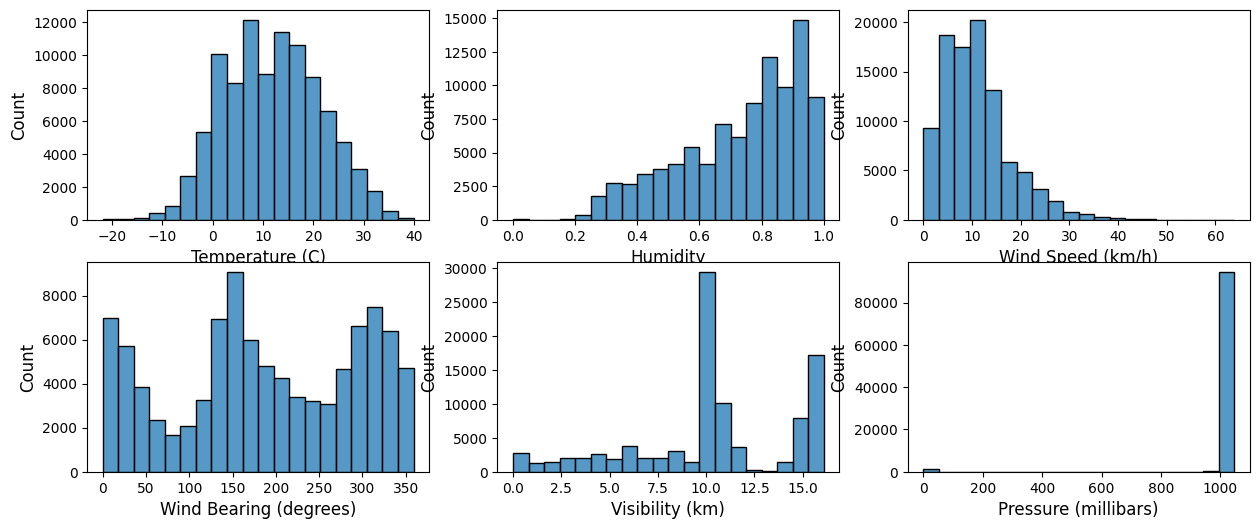

In [8]:
fig, axes=plt.subplots(2,3)
axes=axes.ravel()
for count, col in enumerate(num_col):
    ax=axes[count]
    sns.histplot(data=data_df,x=col,ax=ax,bins=20)
plt.tight_layout

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

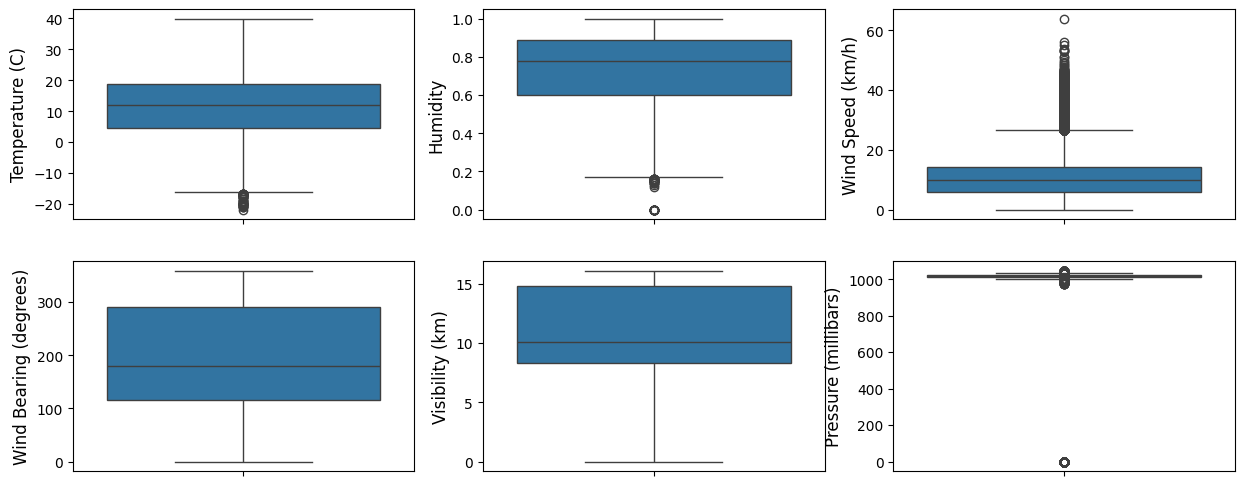

In [9]:
fig, axes=plt.subplots(2,3)
axes=axes.ravel()
for count, col in enumerate(num_col):
    ax=axes[count]
    sns.boxplot(data=data_df,y=col,ax=ax)
plt.tight_layout

<Axes: >

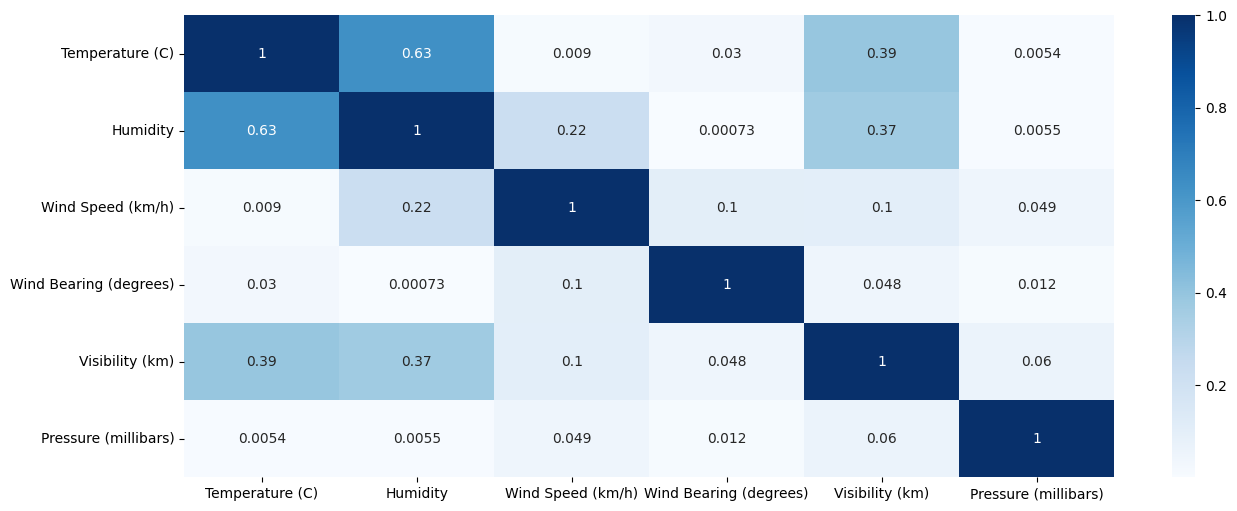

In [10]:
sns.heatmap(data_df[num_col].corr().abs(),annot=True,cmap='Blues')

In [11]:
data_df['datetime']=pd.to_datetime(data_df['Formatted Date'],utc=True)
data_df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,datetime
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,2006-03-31 22:00:00+00:00
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,2006-03-31 23:00:00+00:00
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,2006-04-01 00:00:00+00:00
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,2006-04-01 01:00:00+00:00
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,2006-04-01 02:00:00+00:00


In [12]:
temp_df=data_df[['Temperature (C)','datetime']].copy()
temp_df=temp_df.rename({'Temperature (C)': 'temp'},axis=1)
temp_df=temp_df.reset_index(drop=True)
temp_df.head()

,temp,datetime
0,9.472222,2006-03-31 22:00:00+00:00
1,9.355556,2006-03-31 23:00:00+00:00
2,9.377778,2006-04-01 00:00:00+00:00
3,8.288889,2006-04-01 01:00:00+00:00
4,8.755556,2006-04-01 02:00:00+00:00


<Axes: xlabel='datetime'>

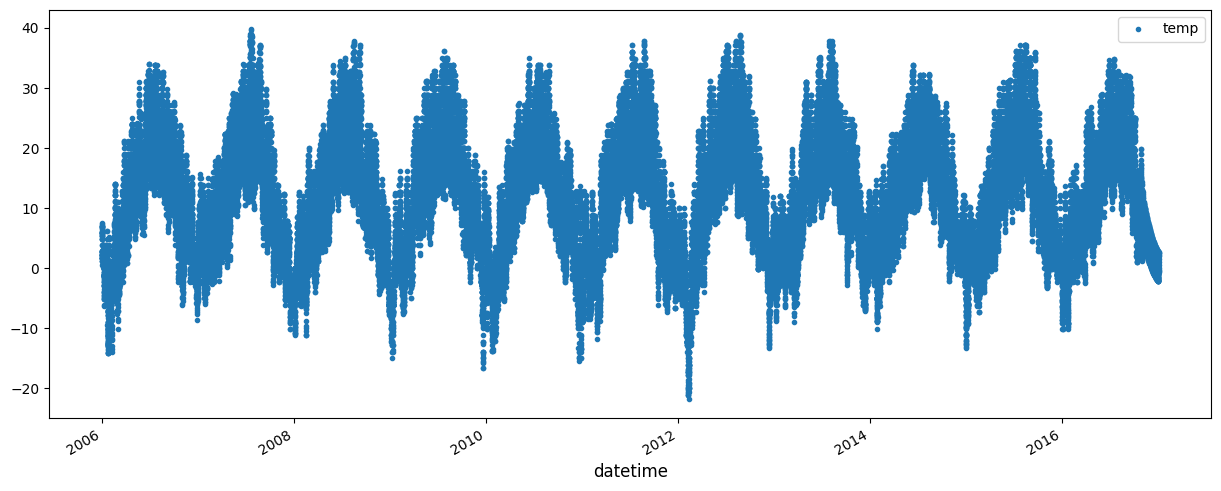

In [14]:
temp_df.plot(x='datetime', y='temp',style='.')

In [19]:
h_units=100
input_shape=(1,10000)
model=tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=input_shape))
model.add(tf.keras.layers.SimpleRNN(units=h_units,activation="tanh"))
model.add(tf.keras.layers.Dense(1,activation="linear"))

In [20]:
wax=model.get_weights()[0].shape
waa=model.get_weights()[1].shape
ba=model.get_weights()[2].shape
way=model.get_weights()[3].shape
by=model.get_weights()[4].shape
print(wax,waa,ba,way,by)

(10000, 100) (100, 100) (100,) (100, 1) (1,)


In [22]:
target_indices=np.arange(TIME_STEPS,len(temp_df),TIME_STEPS)
target_indices.shape

(4018,)

In [24]:
y_df=temp_df.iloc[target_indices].copy()
y_df.head()

,temp,datetime
24,10.422222,2006-04-09 22:00:00+00:00
48,13.772222,2006-04-10 22:00:00+00:00
72,8.200000,2006-04-11 22:00:00+00:00
96,7.316667,2006-04-12 22:00:00+00:00
120,6.622222,2006-04-13 22:00:00+00:00


In [26]:
X_df=temp_df.iloc[:len(y_df) * TIME_STEPS].copy()
X_df.shape,y_df.shape

((96432, 2), (4018, 2))

In [28]:
X=X_df['temp'].to_numpy().reshape(len(y_df),TIME_STEPS)
X.shape

(4018, 24)

In [29]:
X=X[:, :TIME_STEPS-1]# shape (n_sample,time_steps-1)
X.shape

(4018, 23)

In [33]:
y=y_df["temp"].to_numpy()
y.shape

(4018,)

In [34]:
split_idx=int(len(X) * (1-TEST_SIZE))
split_idx=split_idx //BATCH_SIZE * BATCH_SIZE
split_idx

3200

In [35]:
X_train,X_test=X[:split_idx],X[split_idx:]
y_train,y_test=y[:split_idx],y[split_idx:]
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((3200, 23), (818, 23), (3200,), (818,))

In [38]:
X_scaler=StandardScaler()
y_scaler=StandardScaler()

X_train=X_scaler.fit_transform(X_train)

X_test=X_scaler.transform(X_test)

y_train=y_scaler.fit_transform(y_train.reshape(-1,1)).flatten()
y_test=y_scaler.transform(y_test.reshape(-1,1)).flatten()
X_train.shape,X_test.shape,y_train.shape,y_test.shape


((3200, 23), (818, 23), (3200,), (818,))

In [41]:
h_units=64
kernel_initalizer = tf.keras.initializers.GlorotUniform(seed = RANDOM_STATE)

optimizer = 'adam'

loss_fn = 'mean_squared_error'
input_shape=(TIME_STEPS-1,1)

model=tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=input_shape))
model.add(tf.keras.layers.SimpleRNN(units=h_units,
                                    kernel_initializer='kernel_initializer',
                                    activation="tanh"))
model.add(tf.keras.layers.Dense(1,
                                kernel_initializer='kernel_initializer',
                                activation="linear"))

ValueError: Could not interpret initializer identifier: kernel_initializer

In [ ]:
model.compile(optimizer=optimizer,loss=loss_fn,
             metric)

In [ ]:
loss_df=pd.DataFrame

In [ ]:
y_pred

In [ ]:
y_train_pred_scaled=model.predict(X_train)
y_test_pred_scaled

In [40]:
res_df=y_df.copy()
y_df['pred']=y_pred
y-df.plot(x='datetime',y=['temp','pred'])

NameError: name 'y_pred' is not defined